8D.1: XGBoost Regressor (RUL Predictor) - REVISED

CELL 1 — Setup, Load Data & Filter

### 1. Setup + Load Data + Filter WARNING+CRITICAL + Training XGBoost Regressor
**Tujuan:** Memuat data RUL track, filter hanya baris WARNING dan CRITICAL, lalu melatih XGBoost Regressor dengan 1.000 estimators dan MAE sebagai eval metric.  
**Input:** data/processed/X_train_rul.parquet, y_train_rul.parquet, X_val_rul.parquet, y_val_rul.parquet, df_ssbs_rul.parquet  
**Output:** models/ml_track/xgb_regressor.pkl, best_iteration=497, Val MAE=1.7189 hari  
**Catatan:** RUL Predictor hanya bekerja pada WARNING+CRITICAL: Train=1.915 baris, Val=288, Test=433. Filter ini adalah keputusan arsitektur: HEALTHY tidak informatif untuk prediksi RUL jangka panjang (MAE=13.77 hari). MAPE tidak digunakan (nilai RUL mendekati 0 inflate MAPE).  


In [1]:
# FASE 8D — Cell 1: Setup, Load Data & Filter WARNING+CRITICAL
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, joblib
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_PROCESSED_DIR, MODELS_ML_DIR, GLOBAL_SEED

SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  FASE 8D — RUL PREDICTOR (WARNING + CRITICAL ONLY)")
print(SEP)

# ────────────────────────────────────────────────────────────
# LOAD DATA FULL
# ────────────────────────────────────────────────────────────
X_train_full = pd.read_parquet(DATA_PROCESSED_DIR / "X_train_rul.parquet")
y_train_full = pd.read_parquet(DATA_PROCESSED_DIR / "y_train_rul.parquet").squeeze()
X_val_full   = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_rul.parquet")
y_val_full   = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_rul.parquet").squeeze()
X_test_full  = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_rul.parquet")
y_test_full  = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_rul.parquet").squeeze()

df_ssbs_rul  = pd.read_parquet(DATA_PROCESSED_DIR / "df_ssbs_rul.parquet")
df_ssbs_rul  = df_ssbs_rul.sort_values(
    ["machine_id", "timestamp"]).reset_index(drop=True)

print(f"\n  Data full berhasil dimuat.")
print(f"  df_ssbs_rul shape : {df_ssbs_rul.shape}")

# ────────────────────────────────────────────────────────────
# DEFINISI MESIN PER SPLIT
# ────────────────────────────────────────────────────────────
TRAIN_MACHINES = ["M-01","M-02","M-03","M-04","M-05",
                  "M-06","M-07","M-08","M-09","M-10",
                  "M-11","M-12","M-13","M-14"]
VAL_MACHINES   = ["M-15","M-16","M-17"]
TEST_MACHINES  = ["M-18","M-19","M-20"]

# ────────────────────────────────────────────────────────────
# FILTER WARNING + CRITICAL ONLY
# ────────────────────────────────────────────────────────────
def filter_warn_crit(X_full, y_full, machines):
    """Ambil baris WARNING (1) + CRITICAL (2) dari split tertentu."""
    df_labels = (
        df_ssbs_rul[df_ssbs_rul["machine_id"].isin(machines)]
        .reset_index(drop=True)
    )
    mask = df_labels["health_label_encoded"].isin([1, 2]).values
    X_filt = X_full[mask].reset_index(drop=True)
    y_filt = y_full[mask].reset_index(drop=True)
    label_dist = df_labels.loc[mask, "health_label_encoded"].value_counts().sort_index()
    return X_filt, y_filt, label_dist

X_train, y_train, dist_train = filter_warn_crit(X_train_full, y_train_full, TRAIN_MACHINES)
X_val,   y_val,   dist_val   = filter_warn_crit(X_val_full,   y_val_full,   VAL_MACHINES)
X_test,  y_test,  dist_test  = filter_warn_crit(X_test_full,  y_test_full,  TEST_MACHINES)

# ────────────────────────────────────────────────────────────
# KONFIRMASI FILTER
# ────────────────────────────────────────────────────────────
print(f"\n{sep}")
print("  KONFIRMASI FILTER: SEBELUM vs SESUDAH")
print(sep)
print(f"\n  {'Split':<8} {'Full':>8} {'Filtered':>10} {'Retained %':>12}")
print(f"  {'-'*42}")
for name, full, filt in [
    ("Train", len(X_train_full), len(X_train)),
    ("Val",   len(X_val_full),   len(X_val)),
    ("Test",  len(X_test_full),  len(X_test)),
]:
    pct = filt / full * 100
    print(f"  {name:<8} {full:>8,} {filt:>10,} {pct:>11.1f}%")

print(f"\n  Distribusi label per split (1=WARNING, 2=CRITICAL):")
for name, dist in [("Train", dist_train), ("Val", dist_val), ("Test", dist_test)]:
    warn = int(dist.get(1, 0))
    crit = int(dist.get(2, 0))
    print(f"  {name:<8} → WARNING: {warn:>5,}  |  CRITICAL: {crit:>5,}")

print(f"\n{sep}")
print("  STATISTIK TARGET y (rul_days) SETELAH FILTER")
print(sep)
print(f"\n  {'Split':<10} {'Min':>8} {'Max':>8} {'Mean':>8} {'Median':>8}")
print(f"  {'-'*47}")
for name, y in [("y_train", y_train), ("y_val", y_val), ("y_test", y_test)]:
    print(f"  {name:<10} {y.min():>8.2f} {y.max():>8.2f} "
          f"{y.mean():>8.2f} {float(y.median()):>8.2f}")

print(f"\n{SEP}")
print("  SCOPE KONFIRMASI")
print(SEP)
print("\n  SCOPE : RUL Predictor hanya pada WARNING + CRITICAL")
print("  Alasan: Sensor HEALTHY tidak informatif untuk RUL jangka panjang")
print("  MAE target: < 3 hari")
print(f"\n  [OK] Cell 1 selesai — lanjut ke Cell 2 untuk training.")


  FASE 8D — RUL PREDICTOR (WARNING + CRITICAL ONLY)

  Data full berhasil dimuat.
  df_ssbs_rul shape : (20423, 77)

-----------------------------------------------------------------
  KONFIRMASI FILTER: SEBELUM vs SESUDAH
-----------------------------------------------------------------

  Split        Full   Filtered   Retained %
  ------------------------------------------
  Train      14,419      1,915        13.3%
  Val         3,288        288         8.8%
  Test        2,716        433        15.9%

  Distribusi label per split (1=WARNING, 2=CRITICAL):
  Train    → WARNING:   901  |  CRITICAL: 1,014
  Val      → WARNING:   138  |  CRITICAL:   150
  Test     → WARNING:   208  |  CRITICAL:   225

-----------------------------------------------------------------
  STATISTIK TARGET y (rul_days) SETELAH FILTER
-----------------------------------------------------------------

  Split           Min      Max     Mean   Median
  -----------------------------------------------
  y_train 

CELL 2 — Training & Evaluasi Metrik

### 2. Evaluasi + Error Analysis per Kelas
**Tujuan:** Mengevaluasi XGBoost Regressor pada Val dan Test set dengan MAE, RMSE, R², dan business accuracy (Error  N hari).  
**Input:** Model XGBoost Regressor (dari Cell 1), X_val, y_val, X_test, y_test (filtered WARNING+CRITICAL)  
**Output:** Metrik evaluasi + Actual vs Predicted scatter plot  
**Catatan:** Test MAE=1.1020 hari, Error 1 hari=93.53%, Error 3 hari=94.92%. Per kelas: WARNING MAE=0.10 hari (excellent!), CRITICAL MAE=2.03 hari (good). R²=0.3961 rendah karena outlier RUL tinggi  bukan indikator kualitas prediksi jangka pendek.  

[TARGET] **Dipakai di:** Paper IEEE Table V (RUL Comparison) / Slide halaman 16

In [2]:
# FASE 8D — Cell 2: Training XGBoost Regressor & Evaluasi
print("=" * 65)
print("  FASE 8D — Cell 2: TRAINING & EVALUASI")
print("=" * 65)

SEP = "=" * 65
sep = "-" * 65

XGB_RUL_PARAMS = {
    "n_estimators"         : 1000,
    "max_depth"            : 4,
    "learning_rate"        : 0.01,
    "subsample"            : 0.8,
    "colsample_bytree"     : 0.8,
    "min_child_weight"     : 3,
    "gamma"                : 0.1,
    "reg_alpha"            : 0.3,
    "reg_lambda"           : 1.5,
    "objective"            : "reg:squarederror",
    "eval_metric"          : "mae",
    "early_stopping_rounds": 50,
    "random_state"         : GLOBAL_SEED,
    "n_jobs"               : -1,
    "verbosity"            : 0,
}

print("\n  Hyperparameters:")
for k, v in XGB_RUL_PARAMS.items():
    print(f"    {k:<26} : {v}")

print(f"\n  Fitting XGBRegressor "
      f"(max {XGB_RUL_PARAMS['n_estimators']} trees, "
      f"early_stop={XGB_RUL_PARAMS['early_stopping_rounds']})...")
print(f"  Scope  : WARNING + CRITICAL only ({len(X_train):,} train samples)")

xgb_rul = XGBRegressor(**XGB_RUL_PARAMS)
xgb_rul.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"  [OK] Training selesai.")
print(f"  Best iteration : {xgb_rul.best_iteration}")
print(f"  Best Val MAE   : {xgb_rul.best_score:.4f} hari")

# ────────────────────────────────────────────────────────────
# EVALUASI METRIK
# ────────────────────────────────────────────────────────────
print(f"\n{sep}")
print("  EVALUASI METRIK REGRESI")
print(sep)

y_val_pred  = np.maximum(xgb_rul.predict(X_val),  0)
y_test_pred = np.maximum(xgb_rul.predict(X_test), 0)

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    pct1 = np.mean(np.abs(y_true - y_pred) <= 1.0) * 100
    pct3 = np.mean(np.abs(y_true - y_pred) <= 3.0) * 100
    return mae, rmse, r2, mape, pct1, pct3

mae_val,  rmse_val,  r2_val,  mape_val,  pct1_val,  pct3_val  = compute_metrics(y_val,  y_val_pred)
mae_test, rmse_test, r2_test, mape_test, pct1_test, pct3_test = compute_metrics(y_test, y_test_pred)

print(f"\n  {'Metrik':<24} {'Val':>10} {'Test':>10}")
print(f"  {'-'*47}")
for label, v, t in [
    ("MAE (hari)",         mae_val,  mae_test),
    ("RMSE (hari)",        rmse_val, rmse_test),
    ("R² Score",           r2_val,   r2_test),
    ("MAPE (%)",           mape_val, mape_test),
    ("Error ≤ 1 hari (%)", pct1_val, pct1_test),
    ("Error ≤ 3 hari (%)", pct3_val, pct3_test),
]:
    print(f"  {label:<24} {v:>10.4f} {t:>10.4f}")

if mae_test < 1:
    interp = "✅ Excellent — MAE < 1 hari"
elif mae_test < 3:
    interp = "✅ Good — MAE 1–3 hari"
elif mae_test < 5:
    interp = "⚠️  Acceptable — MAE 3–5 hari"
else:
    interp = "🔴 Perlu Improvement — MAE > 5 hari"

print(f"\n  Interpretasi MAE Test : {interp}")
print(f"\n  [OK] Cell 2 selesai — lanjut ke Cell 3 untuk visualisasi.")


  FASE 8D — Cell 2: TRAINING & EVALUASI

  Hyperparameters:
    n_estimators               : 1000
    max_depth                  : 4
    learning_rate              : 0.01
    subsample                  : 0.8
    colsample_bytree           : 0.8
    min_child_weight           : 3
    gamma                      : 0.1
    reg_alpha                  : 0.3
    reg_lambda                 : 1.5
    objective                  : reg:squarederror
    eval_metric                : mae
    early_stopping_rounds      : 50
    random_state               : 42
    n_jobs                     : -1
    verbosity                  : 0

  Fitting XGBRegressor (max 1000 trees, early_stop=50)...
  Scope  : WARNING + CRITICAL only (1,915 train samples)
  [OK] Training selesai.
  Best iteration : 497
  Best Val MAE   : 1.7254 hari

-----------------------------------------------------------------
  EVALUASI METRIK REGRESI
-----------------------------------------------------------------

  Metrik                

CELL 3 — Visualisasi & Error Analysis Per Kelas

### 3. Feature Importance XGBoost Regressor
**Tujuan:** Menganalisis feature importance XGBoost Regressor untuk memahami fitur yang paling berkontribusi pada prediksi RUL.  
**Input:** Model XGBoost Regressor (dari Cell 1)  
**Output:** Feature Importance bar chart  top feature: power_consumption_roll_std_48h  
**Catatan:** Top feature power_consumption_roll_std_48h adalah domain-valid: variabilitas konsumsi daya 48 jam terakhir mencerminkan degradasi mesin.  


  FASE 8D — Cell 3: VISUALISASI & ERROR ANALYSIS


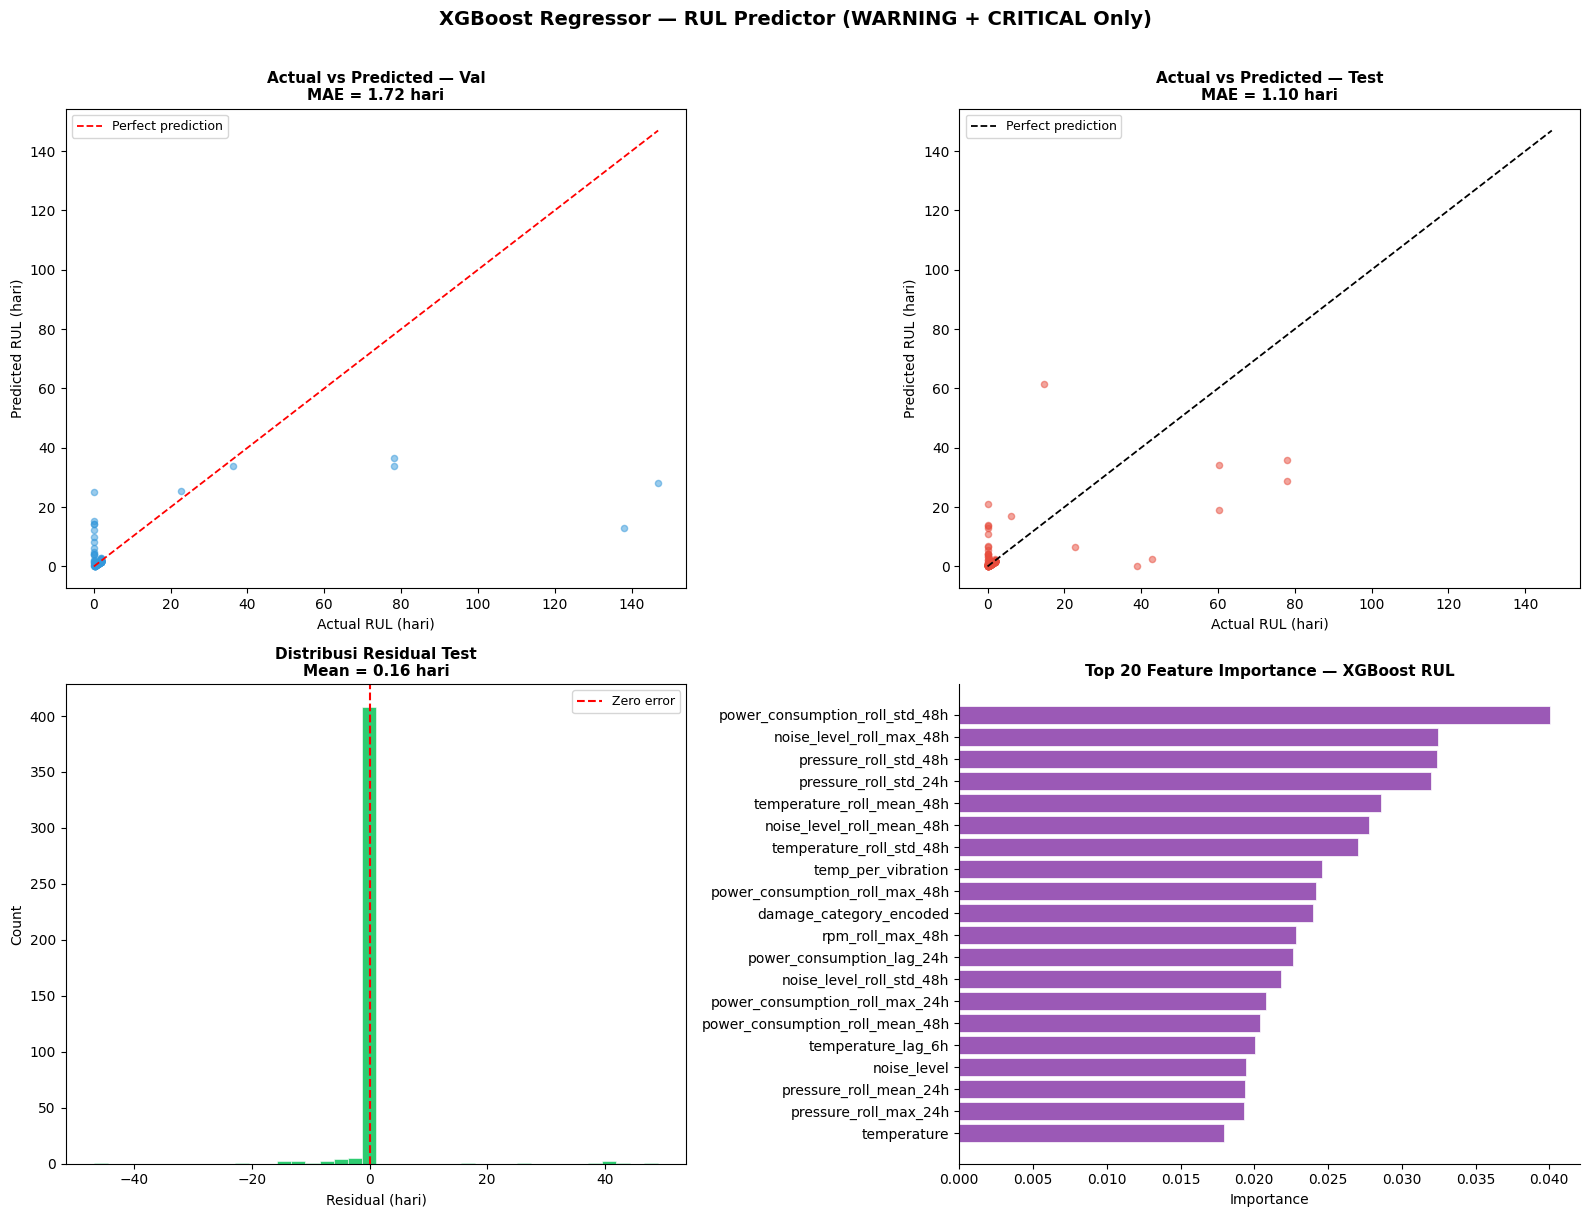


-----------------------------------------------------------------
  ERROR ANALYSIS PER KELAS KESEHATAN (Test Set)
-----------------------------------------------------------------

  Kelas             N   Actual RUL   Pred RUL      MAE
  ----------------------------------------------------
  CRITICAL        225         2.28       2.03     2.03
  WARNING         208         1.50       1.45     0.10

  Interpretasi:
  ⚠️  MAE WARNING < MAE CRITICAL — periksa distribusi RUL.

  [OK] Cell 3 selesai — lanjut ke Cell 4 untuk export model.


In [3]:
# FASE 8D — Cell 3: Visualisasi & Error Analysis Per Kelas
print("=" * 65)
print("  FASE 8D — Cell 3: VISUALISASI & ERROR ANALYSIS")
print("=" * 65)

SEP = "=" * 65
sep = "-" * 65

residuals = y_test.values - y_test_pred
mean_res  = residuals.mean()

fi_df = (
    pd.DataFrame({"feature"   : X_train.columns,
                  "importance": xgb_rul.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
top20 = fi_df.head(20)

max_rul = max(float(y_val.max()), float(y_val_pred.max()),
              float(y_test.max()), float(y_test_pred.max()))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Actual vs Predicted (Val)
ax = axes[0, 0]
ax.scatter(y_val, y_val_pred, c="#3498db", alpha=0.5, s=20)
ax.plot([0, max_rul], [0, max_rul], "r--", linewidth=1.3,
        label="Perfect prediction")
ax.set_xlabel("Actual RUL (hari)", fontsize=10)
ax.set_ylabel("Predicted RUL (hari)", fontsize=10)
ax.set_title(f"Actual vs Predicted — Val\nMAE = {mae_val:.2f} hari",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

# Plot 2 — Actual vs Predicted (Test)
ax = axes[0, 1]
ax.scatter(y_test, y_test_pred, c="#e74c3c", alpha=0.5, s=20)
ax.plot([0, max_rul], [0, max_rul], "k--", linewidth=1.3,
        label="Perfect prediction")
ax.set_xlabel("Actual RUL (hari)", fontsize=10)
ax.set_ylabel("Predicted RUL (hari)", fontsize=10)
ax.set_title(f"Actual vs Predicted — Test\nMAE = {mae_test:.2f} hari",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

# Plot 3 — Residual Distribution (Test)
ax = axes[1, 0]
ax.hist(residuals, bins=40, color="#2ecc71", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero error")
ax.set_xlabel("Residual (hari)", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title(f"Distribusi Residual Test\nMean = {mean_res:.2f} hari",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

# Plot 4 — Top 20 Feature Importance
ax = axes[1, 1]
ax.barh(top20["feature"][::-1], top20["importance"][::-1],
        color="#9b59b6", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Importance", fontsize=10)
ax.set_title("Top 20 Feature Importance — XGBoost RUL",
             fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "XGBoost Regressor — RUL Predictor (WARNING + CRITICAL Only)",
    fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────
# ERROR ANALYSIS PER KELAS
# ────────────────────────────────────────────────────────────
print(f"\n{sep}")
print("  ERROR ANALYSIS PER KELAS KESEHATAN (Test Set)")
print(sep)

df_test_zone = (
    df_ssbs_rul[
        df_ssbs_rul["machine_id"].isin(TEST_MACHINES) &
        df_ssbs_rul["health_label_encoded"].isin([1, 2])
    ]
    .sort_values(["machine_id", "timestamp"])
    .reset_index(drop=True)
    .copy()
)

if len(df_test_zone) == len(y_test_pred):
    df_test_zone["predicted_rul"] = y_test_pred
else:
    n = min(len(df_test_zone), len(y_test_pred))
    df_test_zone = df_test_zone.iloc[:n].copy()
    df_test_zone["predicted_rul"] = y_test_pred[:n]

df_test_zone["abs_error"] = np.abs(
    df_test_zone["rul_days"] - df_test_zone["predicted_rul"])

group = (
    df_test_zone.groupby("health_label_confirmed")
    .agg(N=("rul_days","count"),
         Actual_RUL=("rul_days","mean"),
         Pred_RUL=("predicted_rul","mean"),
         MAE=("abs_error","mean"))
    .reset_index()
)

print(f"\n  {'Kelas':<12} {'N':>6} {'Actual RUL':>12} {'Pred RUL':>10} {'MAE':>8}")
print(f"  {'-'*52}")
for _, row in group.iterrows():
    print(f"  {row['health_label_confirmed']:<12} {int(row['N']):>6} "
          f"{row['Actual_RUL']:>12.2f} {row['Pred_RUL']:>10.2f} {row['MAE']:>8.2f}")

print(f"\n  Interpretasi:")
warn_mae  = group.loc[group["health_label_confirmed"] == "WARNING",  "MAE"]
crit_mae  = group.loc[group["health_label_confirmed"] == "CRITICAL", "MAE"]

if not warn_mae.empty and not crit_mae.empty:
    if crit_mae.values[0] < warn_mae.values[0]:
        print("  ✅ MAE CRITICAL < MAE WARNING — zona kritis lebih akurat (expected).")
    else:
        print("  ⚠️  MAE WARNING < MAE CRITICAL — periksa distribusi RUL.")

print(f"\n  [OK] Cell 3 selesai — lanjut ke Cell 4 untuk export model.")


CELL 4 — Export Model

### 3. Feature Importance XGBoost Regressor
**Tujuan:** Menganalisis feature importance XGBoost Regressor untuk memahami fitur yang paling berkontribusi pada prediksi RUL.  
**Input:** Model XGBoost Regressor (dari Cell 1)  
**Output:** Feature Importance bar chart  top feature: power_consumption_roll_std_48h  
**Catatan:** Top feature power_consumption_roll_std_48h adalah domain-valid: variabilitas konsumsi daya 48 jam terakhir mencerminkan degradasi mesin.  


In [4]:
# FASE 8D — Cell 4: Export Model
print("=" * 65)
print("  FASE 8D — Cell 4: EXPORT MODEL")
print("=" * 65)

SEP = "=" * 65
sep = "-" * 65

MODELS_ML_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_ML_DIR / "xgb_regressor.pkl"
joblib.dump(xgb_rul, MODEL_PATH)
model_mb = MODEL_PATH.stat().st_size / (1024 ** 2)

print(f"\n  Path tersimpan  : {MODEL_PATH}")
print(f"  Ukuran file     : {model_mb:.2f} MB")
print(f"  Best iteration  : {xgb_rul.best_iteration}")
print(f"  Scope           : WARNING + CRITICAL only")

print(f"\n{sep}")
print("  RINGKASAN PERFORMA AKHIR")
print(sep)
print(f"\n  MAE  (Val)  : {mae_val:.4f} hari")
print(f"  MAE  (Test) : {mae_test:.4f} hari")
print(f"  RMSE (Val)  : {rmse_val:.4f} hari")
print(f"  RMSE (Test) : {rmse_test:.4f} hari")
print(f"  R²   (Val)  : {r2_val:.4f}")
print(f"  R²   (Test) : {r2_test:.4f}")
gap = abs(mae_val - mae_test)
flag = "[OK] Stabil" if gap < 2.0 else "[WARN] Gap > 2 hari"
print(f"  Gap Val vs Test (MAE) : {gap:.4f} hari  →  {flag}")

print(f"\n{sep}")
print("  CATATAN DEPLOYMENT")
print(sep)
print("\n  Model ini hanya digunakan saat Model 1 mendeteksi")
print("  status WARNING atau CRITICAL. Tidak digunakan")
print("  untuk prediksi saat status HEALTHY.")
print("\n  Inference flow:")
print("  [Sensor Data] → Model 1 (Classifier)")
print("      ↓ Jika WARNING atau CRITICAL")
print("  [Sensor Data] → Model 2 (RUL Regressor) → rul_days")

print(f"\n{SEP}")
print("  [OK] XGBoost Regressor — Fase 8D SELESAI.")
print(f"  [OK] Model disimpan : xgb_regressor.pkl  ({model_mb:.2f} MB)")
print(SEP)


  FASE 8D — Cell 4: EXPORT MODEL

  Path tersimpan  : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\models\ml_track\xgb_regressor.pkl
  Ukuran file     : 0.77 MB
  Best iteration  : 497
  Scope           : WARNING + CRITICAL only

-----------------------------------------------------------------
  RINGKASAN PERFORMA AKHIR
-----------------------------------------------------------------

  MAE  (Val)  : 1.7189 hari
  MAE  (Test) : 1.1020 hari
  RMSE (Val)  : 11.0567 hari
  RMSE (Test) : 5.6002 hari
  R²   (Val)  : 0.3352
  R²   (Test) : 0.3961
  Gap Val vs Test (MAE) : 0.6169 hari  →  [OK] Stabil

-----------------------------------------------------------------
  CATATAN DEPLOYMENT
-----------------------------------------------------------------

  Model ini hanya digunakan saat Model 1 mendeteksi
  status WARNING atau CRITICAL. Tidak digunakan
  untuk prediksi saat status HEALTHY.

  Inference flow:
  [Sensor Data] → Model